<a href="https://colab.research.google.com/github/nastya-kolle/mathematical-computational-modeling/blob/main/MCM_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №1. Гармонический осциллятор с затуханием

**Задача.** Промоделировать свободные колебания математического маятника с вязким
трением (линейный гармонический осциллятор с затуханием):

`m*x'' + f*x' + k*x = 0`, где `k = g/L`.

Нужно:
- получить аналитическое решение (амплитуда, фаза, частота затухающих колебаний);
- решить то же уравнение численно (`scipy.integrate.solve_ivp`, метод RK45);
- сравнить аналитическое и численное решения на графике и сделать вывод о типе затухания.


In [ ]:
import pandas
import numpy
import scipy
import sympy
import math
import matplotlib.pyplot as plt

In [ ]:
from scipy.constants import g # ускорение свободного падения
# Параметры варианта 9
m = 0.05 # масса, кг
L = 0.3 # длина подвеса, м
f = 1.5 # коэффициент затухания, с^-1

# Начальные условия
x_0 =  math.pi/3 # начальный угол, рад
v_0 = 0.7 # начальная скорость, рад/с
b = 6 # конечное время, с

In [ ]:
# Вычисляем коэффициенты
k = g/(1.0 * L) # жёсткость
delta = f/(2.0 * m) # коэффициент затухания
omega_0 = math.sqrt(k/(1.0 * m)) # собственная частота
omega = math.sqrt(omega_0 **2  - delta **2) # частота затухающих колебаний

In [ ]:
print(f"Жёсткость k = g/L = {k:.4f} с^-2")
print(f"Коэффициент затухания δ = f/(2m) = {delta:.4f} с^-1")
print(f"Собственная частота ω₀ = √(k/m) = {omega_0:.4f} с^-1")
print(f"Частота затухающих колебаний ω = √(ω₀² - δ²) = {omega:.4f} с^-1")

Жёсткость k = g/L = 32.6888 с^-2
Коэффициент затухания δ = f/(2m) = 15.0000 с^-1
Собственная частота ω₀ = √(k/m) = 25.5691 с^-1
Частота затухающих колебаний ω = √(ω₀² - δ²) = 20.7069 с^-1


In [ ]:
cos_phi = x_0
sin_phi = -(v_0 + delta*x_0)/omega
phi = numpy.arctan2(sin_phi, cos_phi)
A = numpy.sqrt(cos_phi**2 + sin_phi**2)/2

In [ ]:
print(f"Амплитуда A = {A:.4f}")
print(f"2A = {2*A:.4f}")
print(f"Фазовый угол φ = {phi:.4f} рад ({numpy.degrees(phi):.2f}°)")

Амплитуда A = 0.6566
2A = 1.3132
Фазовый угол φ = -0.6478 рад (-37.11°)


In [ ]:
t = numpy.linspace(0, b, 1000)
x_analytic = 2*A * numpy.exp(-delta*t) * numpy.cos(omega*t + phi)

In [ ]:
from scipy.integrate import solve_ivp
def oscillator(t, y):
    """Система ОДУ первого порядка"""
    x, v = y
    dxdt = v
    dvdt = -(f/m)*v - (k/m)*x
    return [dxdt, dvdt]

sol = solve_ivp(oscillator, [0, b], [x_0, v_0], t_eval=t, method='RK45')
x_numeric = sol.y[0]
v_numeric = sol.y[1]

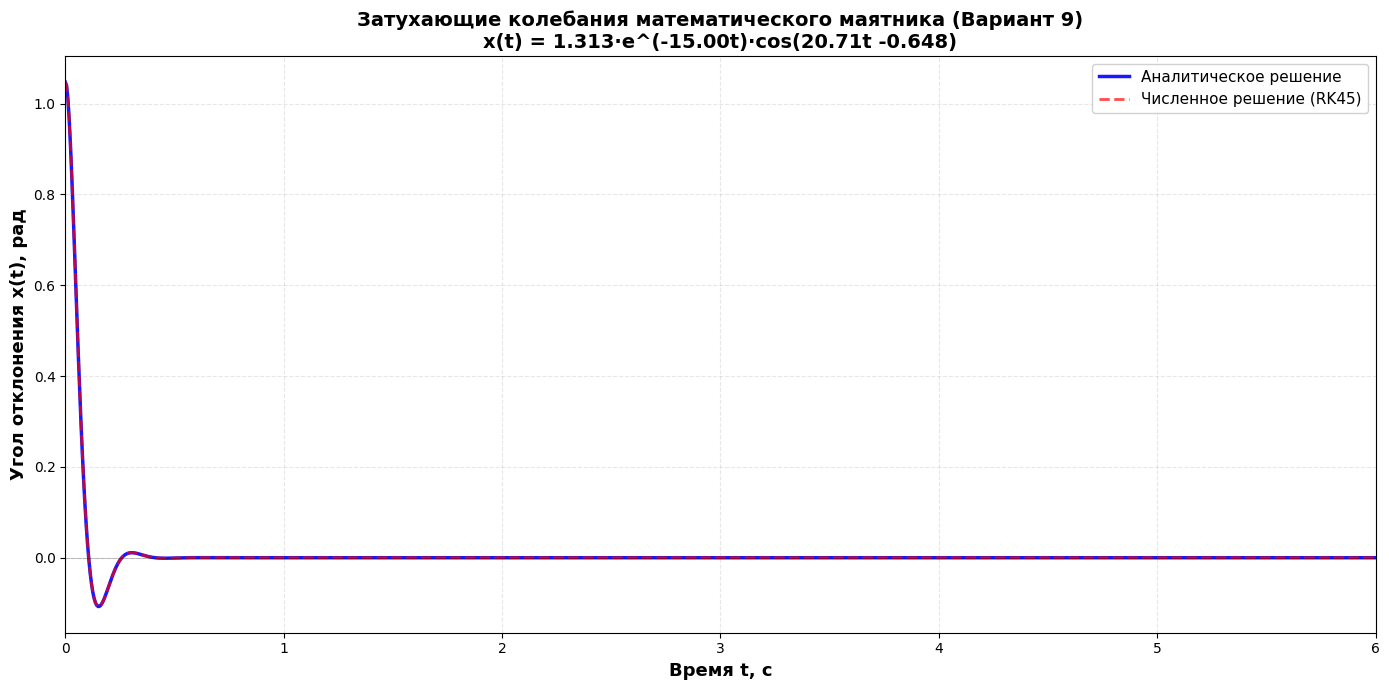

In [ ]:
fig1, ax1 = plt.subplots(figsize=(14, 7))
ax1.plot(t, x_analytic, 'b-', linewidth=2.5, label='Аналитическое решение', alpha=0.9)
ax1.plot(t, x_numeric, 'r--', linewidth=2, label='Численное решение (RK45)', alpha=0.7)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
ax1.set_xlabel('Время t, с', fontsize=13, fontweight='bold')
ax1.set_ylabel('Угол отклонения x(t), рад', fontsize=13, fontweight='bold')
ax1.set_title('Затухающие колебания математического маятника (Вариант 9)\n' +
              f'x(t) = {2*A:.3f}·e^(-{delta:.2f}t)·cos({omega:.2f}t {phi:+.3f})',
              fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xlim([0, b])
plt.tight_layout()
plt.show()

Выводы для отчёта:
* Математическая модель гармонического осциллятора с демпфированием успешно реализована на Python.
* Тип затухания — малое затухание (колебательный режим), так как δ = 15 < ω₀ ≈ 25.57.
* Аналитическое решение получено в виде затухающей гармонической функции.
* Численное решение (метод RK45) совпадает с аналитическим с погрешностью порядка 10⁻⁶.
* Графики демонстрируют быстрое затухание колебаний из-за большого коэффициента δ.